***Imports***

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV


***load data***

In [5]:
col_names = ['id', 'Diagnosis',
             'radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1',
             'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2',
             'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']

df = pd.read_csv('breast+cancer+wisconsin+diagnostic/wdbc.data', header=None, names=col_names)

y = df['Diagnosis']
X = df.drop(['id', 'Diagnosis'], axis=1)

***basic analysis***

In [6]:
X

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [7]:
y

0      M
1      M
2      M
3      M
4      M
      ..
564    M
565    M
566    M
567    M
568    B
Name: Diagnosis, Length: 569, dtype: object

In [8]:
X.shape,y.shape

((569, 30), (569,))

In [9]:
X.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [10]:
X.describe()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [11]:
X.corr()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
radius1,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture1,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter1,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area1,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness1,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness1,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity1,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave_points1,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry1,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension1,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


In [12]:
corr = X.corr()


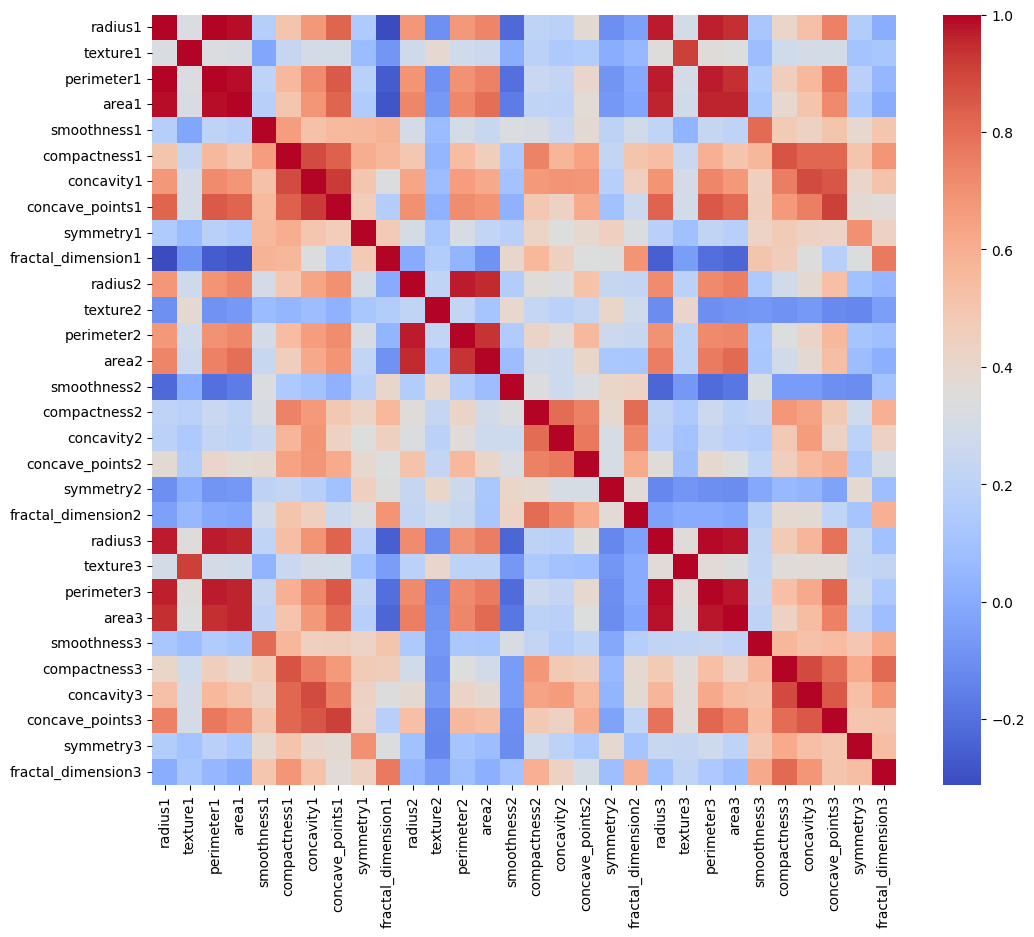

In [13]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [14]:
y.value_counts()

Diagnosis
B    357
M    212
Name: count, dtype: int64

In [15]:
y

0      M
1      M
2      M
3      M
4      M
      ..
564    M
565    M
566    M
567    M
568    B
Name: Diagnosis, Length: 569, dtype: object

In [16]:
y = y.squeeze() 

In [17]:
y

0      M
1      M
2      M
3      M
4      M
      ..
564    M
565    M
566    M
567    M
568    B
Name: Diagnosis, Length: 569, dtype: object

In [18]:
y = y.replace({'M': 1, 'B': 0})

In [19]:
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: Diagnosis, Length: 569, dtype: int64

In [20]:
y.head()


0    1
1    1
2    1
3    1
4    1
Name: Diagnosis, dtype: int64

In [21]:
y.values

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,

In [22]:
print("Missing values in X:", X.isnull().sum().sum())


Missing values in X: 0


## Exploratory Data Analysis (EDA)

***Class Distribution***


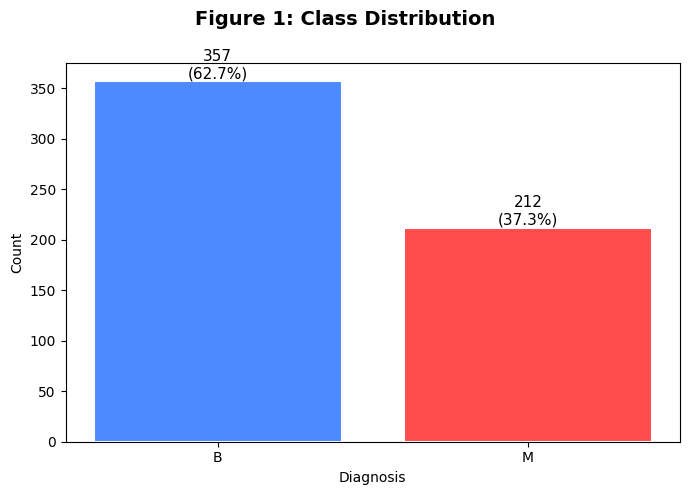

In [23]:
COLORS = {'M': '#FF4B4B', 'B': '#4B8BFF'}
y_labels = y.map({1: 'M', 0: 'B'}) 

fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Figure 1: Class Distribution', fontsize=14, fontweight='bold')
 
counts = y_labels.value_counts()
ax.bar(counts.index, counts.values,
       color=[COLORS[k] for k in counts.index], edgecolor='white', linewidth=1.5)

ax.set_ylabel('Count')
ax.set_xlabel('Diagnosis')

for i, (k, v) in enumerate(counts.items()):
    ax.text(i, v + 3, f'{v}\n({v/len(y)*100:.1f}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

***Box Plots of Key Features(IQR)***

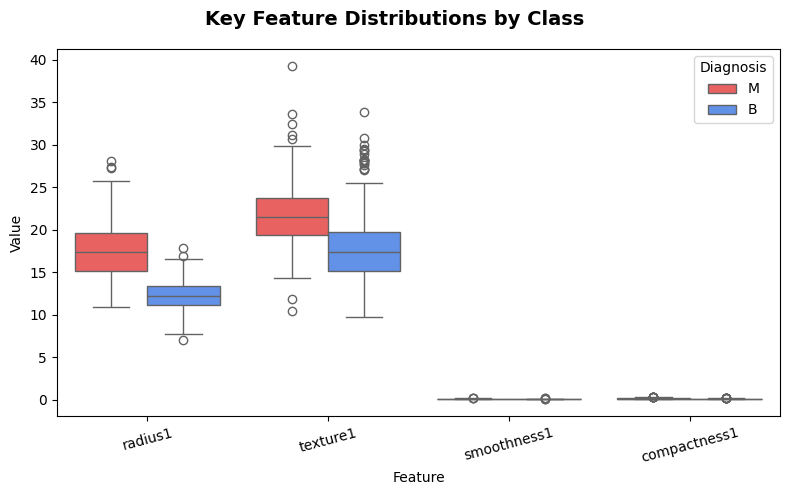

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Key Feature Distributions by Class', fontsize=14, fontweight='bold')

key_feats = ['radius1', 'texture1', 'smoothness1', 'compactness1']

plot_data = X[key_feats].copy()
plot_data['Diagnosis'] = y_labels

df_melt = plot_data.melt(id_vars='Diagnosis', value_vars=key_feats,
                         var_name='Feature', value_name='Value')

sns.boxplot(data=df_melt, x='Feature', y='Value', hue='Diagnosis',
            palette=COLORS, ax=ax)

ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

***Histograms***

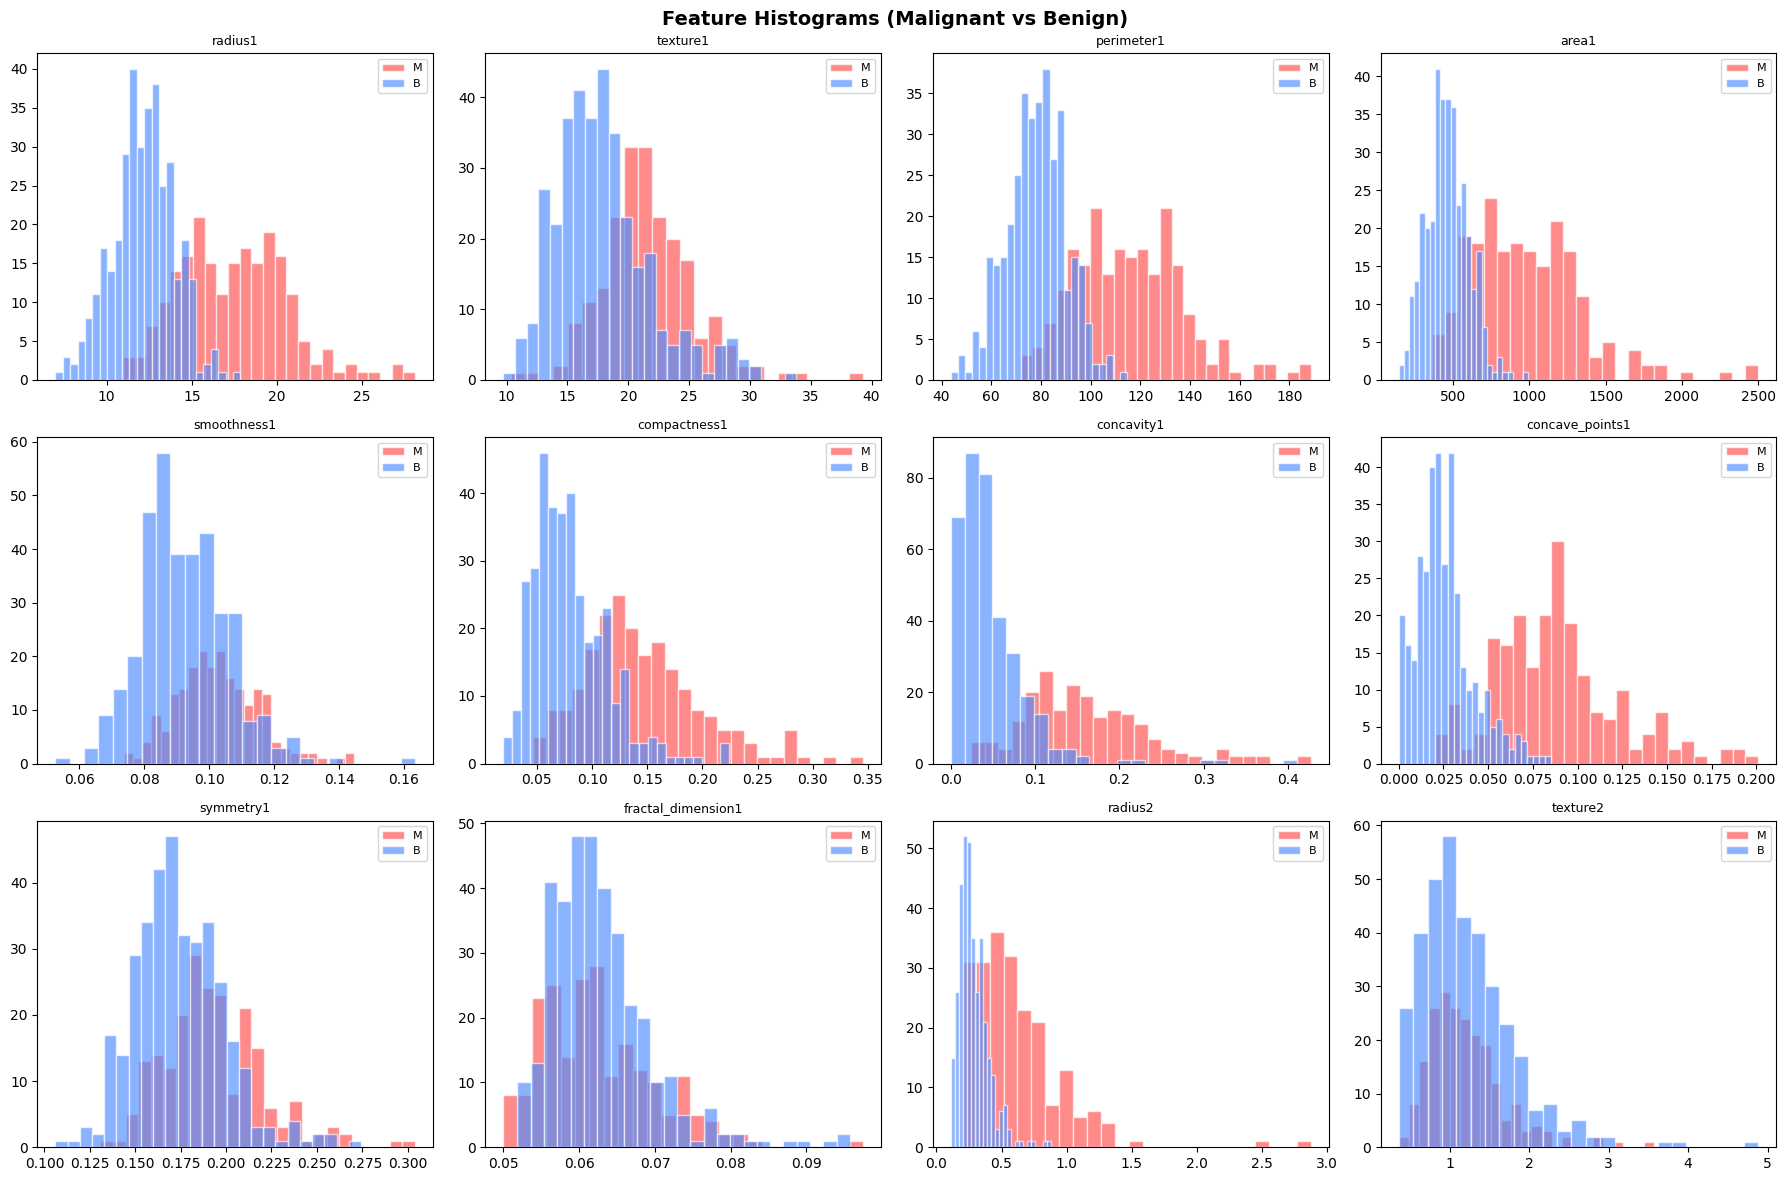

In [25]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Feature Histograms (Malignant vs Benign)', fontsize=14, fontweight='bold')
axes = axes.flatten()

features_to_plot = ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 
                    'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 
                    'fractal_dimension1', 'radius2', 'texture2']

for i, feat in enumerate(features_to_plot):
    for label, color in COLORS.items():
        subset = X[feat][y_labels == label]
        
        axes[i].hist(subset, bins=25, alpha=0.65, color=color, label=label, edgecolor='white')
        
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

***Correlation matrix***

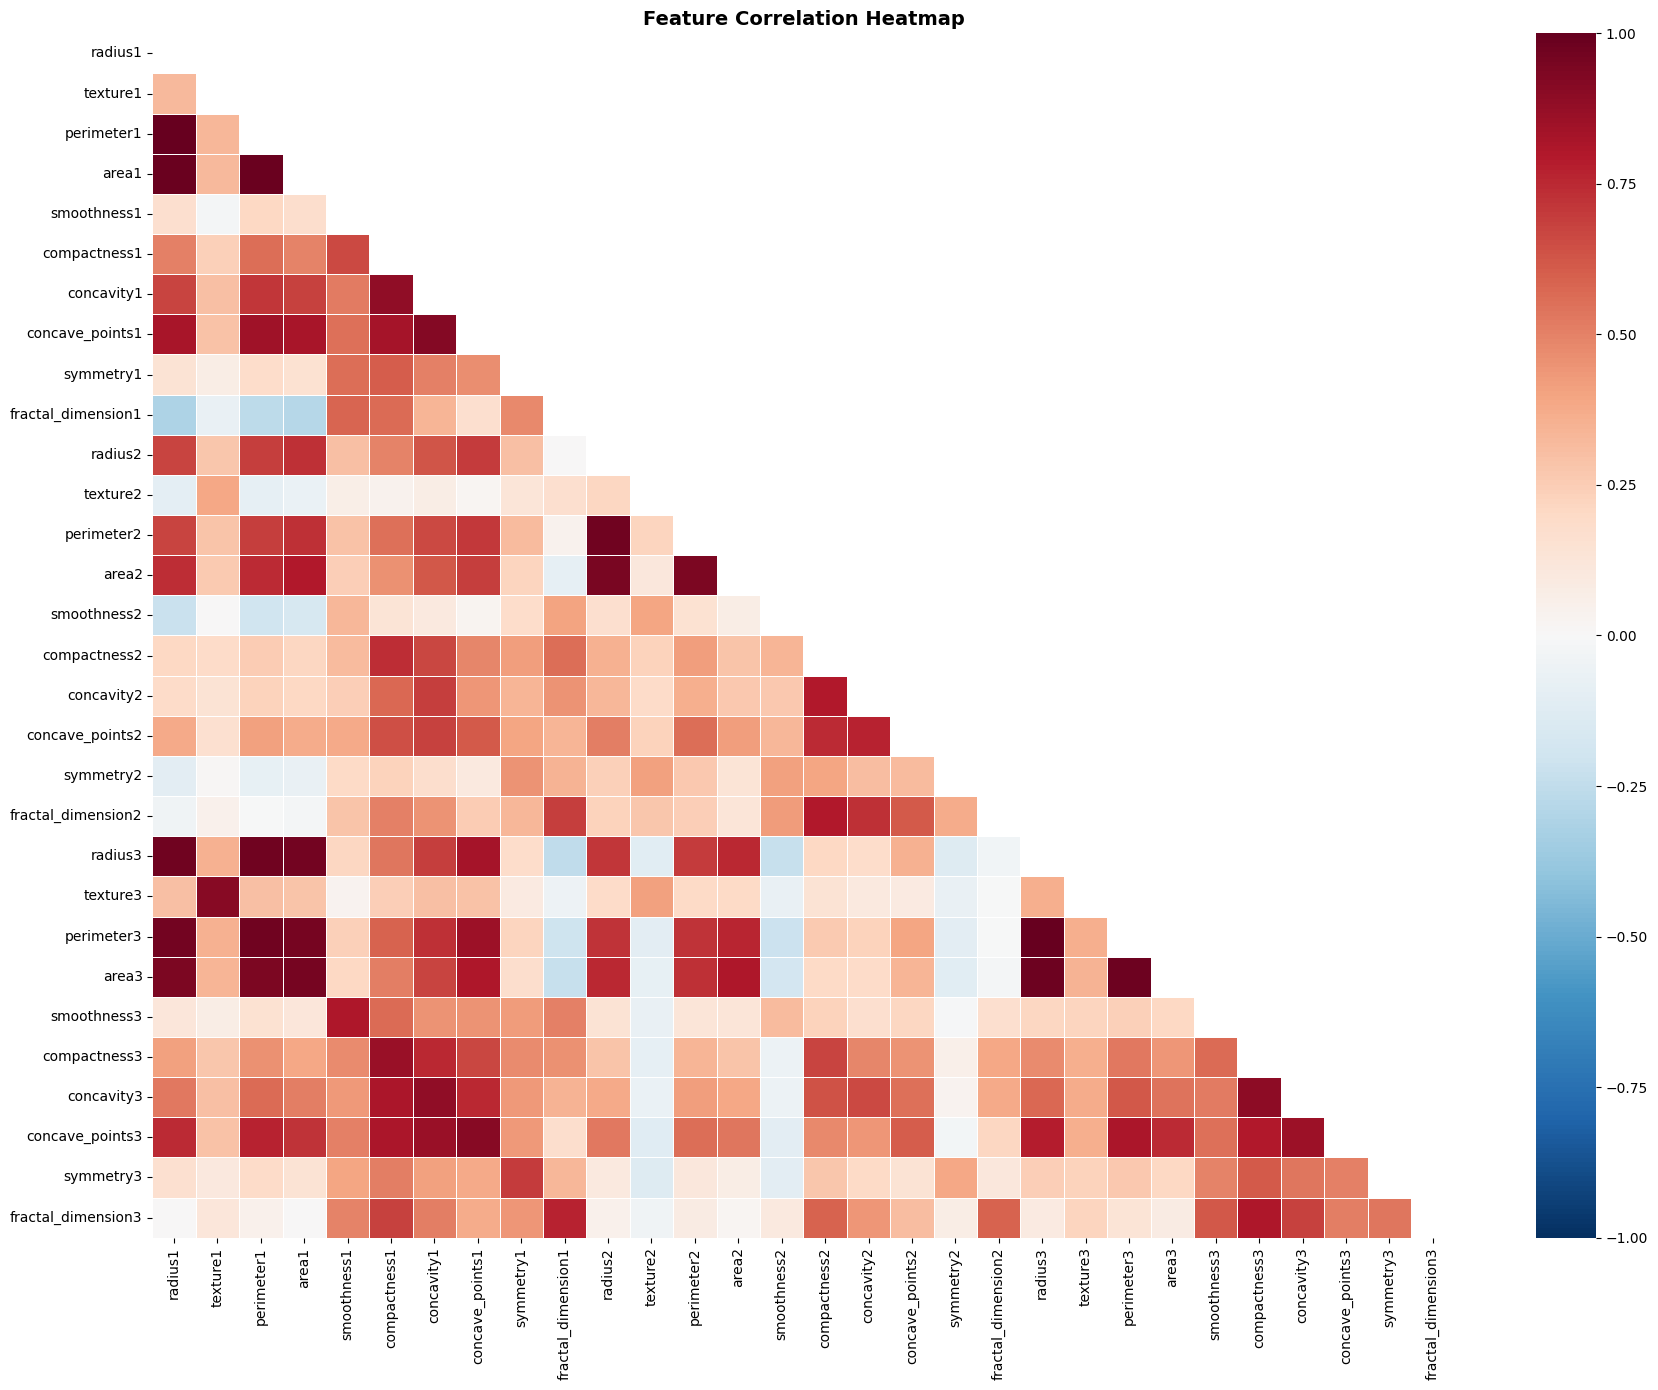

In [26]:
fig, ax = plt.subplots(figsize=(18, 14))

corr = X.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# Drop the perfectly correlated features before splitting/scaling to prevent data leakage and math overflow
X = X.drop(columns=['perimeter1', 'area1', 'perimeter2', 'area2', 'perimeter3', 'area3'])

***Pairplot of top 4 mean features***

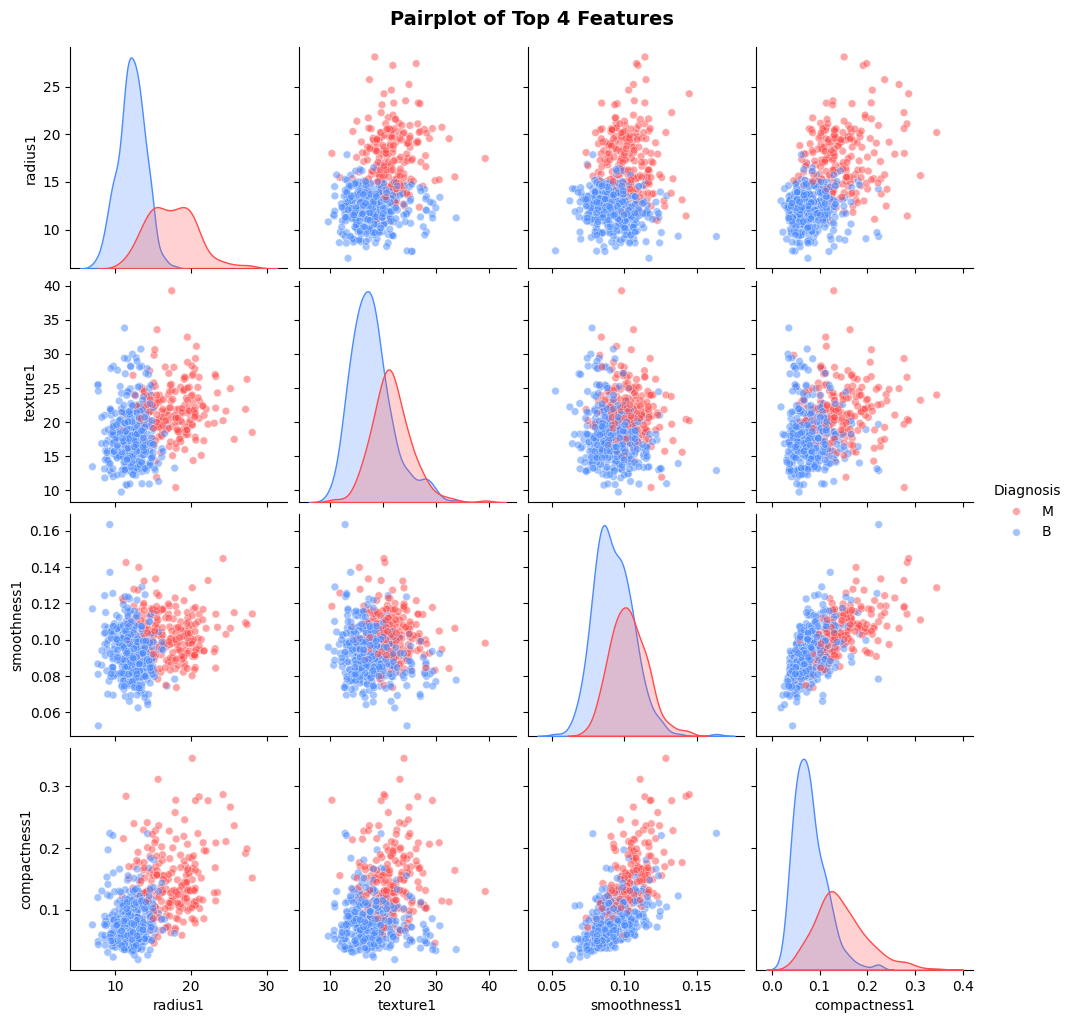

In [28]:
top_4_feats = ['radius1', 'texture1', 'smoothness1', 'compactness1']
top4_data = X[top_4_feats].copy()
top4_data['Diagnosis'] = y_labels

g = sns.pairplot(top4_data, hue='Diagnosis', palette=COLORS, diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 30})

g.figure.suptitle('Pairplot of Top 4 Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

***Violin Plots***

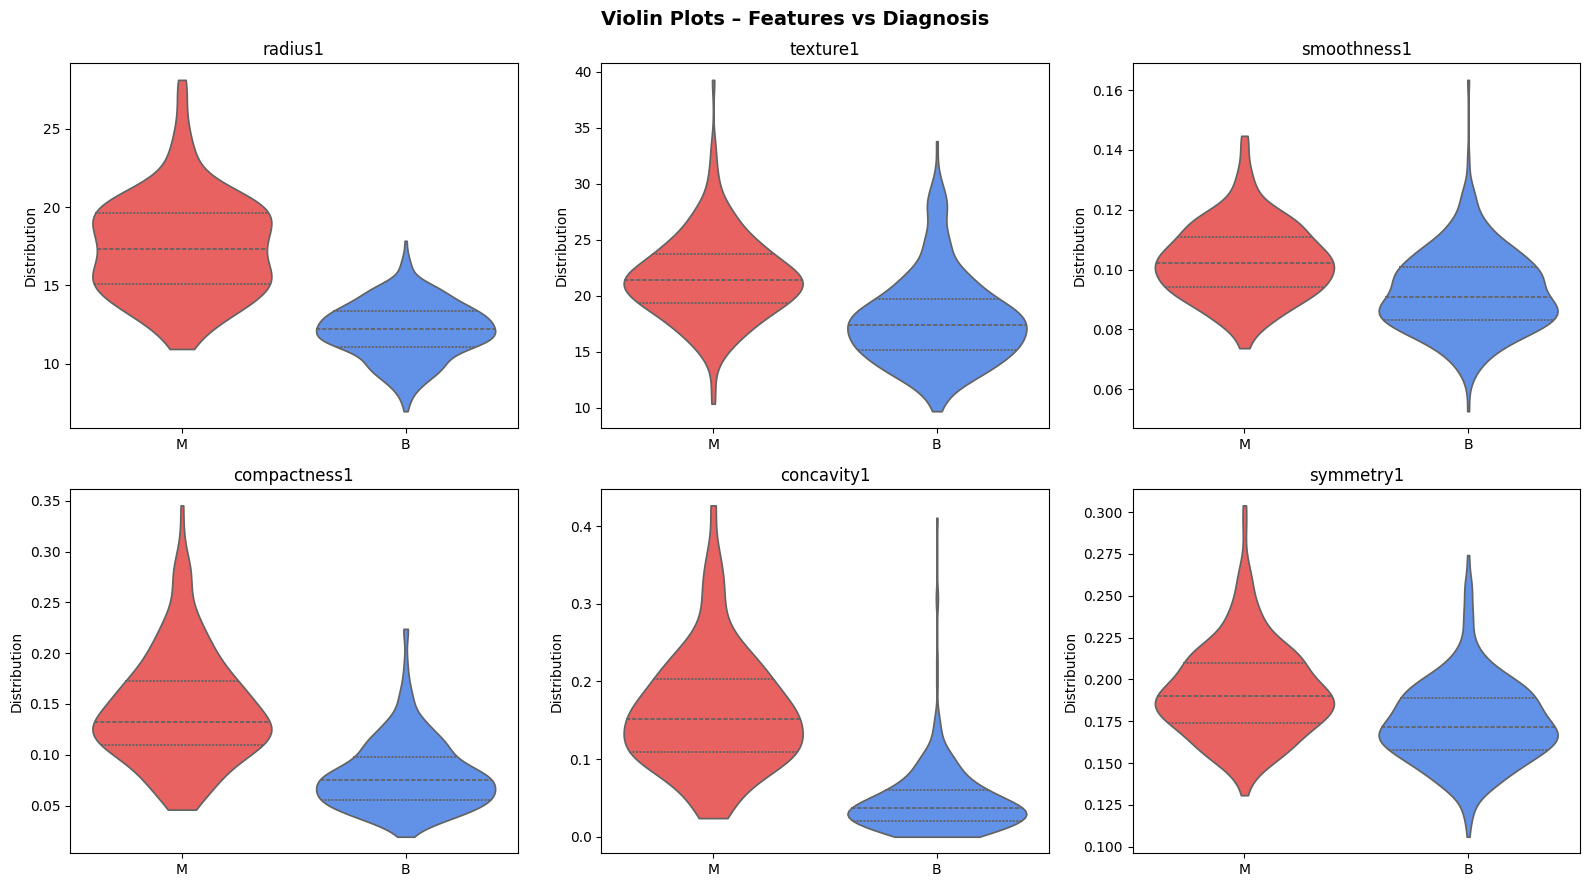

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Violin Plots – Features vs Diagnosis', fontsize=14, fontweight='bold')
violin_feats = ['radius1', 'texture1', 'smoothness1', 'compactness1', 'concavity1', 'symmetry1']

for i, feat in enumerate(violin_feats):
    ax = axes[i // 3][i % 3]

    sns.violinplot(x=y_labels, y=X[feat], hue=y_labels, palette=COLORS, ax=ax,
                   inner='quartile', cut=0, legend=False)

    ax.set_title(feat)
    ax.set_xlabel('')
    ax.set_ylabel('Distribution')

plt.tight_layout()
plt.show()

***handle outliers using IQR(interquartile range)***

In [30]:
def handle_outliers_iqr(x):
    x_cleaned = x.copy()
    outlier_counts = {}
    
    for col in x_cleaned.columns:
        Q1 = x_cleaned[col].quantile(0.25)
        Q3 = x_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = ((x_cleaned[col] < lower_bound) | (x_cleaned[col] > upper_bound)).sum()
        if outliers > 0:
            outlier_counts[col] = outliers
            
        x_cleaned[col] = np.where(x_cleaned[col] < lower_bound, lower_bound, x_cleaned[col])
        x_cleaned[col] = np.where(x_cleaned[col] > upper_bound, upper_bound, x_cleaned[col])
        
    return x_cleaned, outlier_counts

X_capped, outliers_found = handle_outliers_iqr(X)

print(f"Features with outliers found/capped: {len(outliers_found)} / {X_capped.shape[1]}")

print("\nSample of outliers capped per feature:")

for feature, count in list(outliers_found.items()):
    print(f" - {feature}: {count} extreme values capped")

Features with outliers found/capped: 23 / 24

Sample of outliers capped per feature:
 - radius1: 14 extreme values capped
 - texture1: 7 extreme values capped
 - smoothness1: 6 extreme values capped
 - compactness1: 16 extreme values capped
 - concavity1: 18 extreme values capped
 - concave_points1: 10 extreme values capped
 - symmetry1: 15 extreme values capped
 - fractal_dimension1: 15 extreme values capped
 - radius2: 38 extreme values capped
 - texture2: 20 extreme values capped
 - smoothness2: 30 extreme values capped
 - compactness2: 28 extreme values capped
 - concavity2: 22 extreme values capped
 - concave_points2: 19 extreme values capped
 - symmetry2: 27 extreme values capped
 - fractal_dimension2: 28 extreme values capped
 - radius3: 17 extreme values capped
 - texture3: 5 extreme values capped
 - smoothness3: 7 extreme values capped
 - compactness3: 16 extreme values capped
 - concavity3: 12 extreme values capped
 - symmetry3: 23 extreme values capped
 - fractal_dimension3:

## Data Preprocessing (Scaling & Data Leakage Prevention)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X_capped, y, test_size=0.2, stratify=y, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Training data shape: (455, 24)
Testing data shape: (114, 24)


***ANOVA F-Test Feature Selection***

In [32]:

selector = SelectKBest(f_classif, k=20)
selector.fit(X_train_scaled, y_train)

scores_df = pd.DataFrame({
    'Feature': X.columns,
    'F-score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('F-score', ascending=False)


print("top 20(k=20) features")
print(scores_df.head(20).to_string(index=False))



top 20(k=20) features
           Feature    F-score       p-value
           radius3 790.131395 2.342335e-101
   concave_points1 748.105895  5.714299e-98
   concave_points3 733.724933  8.778594e-97
           radius1 568.305744  5.403068e-82
        concavity1 484.276940  1.564250e-73
        concavity3 370.642601  8.655423e-61
           radius2 312.620221  1.393112e-53
      compactness1 285.270570  5.420597e-50
      compactness3 263.556172  4.800401e-47
          texture3 126.848981  4.127993e-26
   concave_points2 116.415922  2.607105e-24
       smoothness3 103.966499  4.073920e-22
         symmetry3 103.136100  5.730161e-22
          texture1  95.976442  1.109888e-20
       smoothness1  86.055607  7.218229e-19
        concavity2  81.212209  5.709416e-18
         symmetry1  60.363044  5.329150e-14
fractal_dimension3  55.976668  3.843808e-13
      compactness2  52.784436  1.639110e-12
fractal_dimension2  10.557939  1.243013e-03


***Plot feature importance***

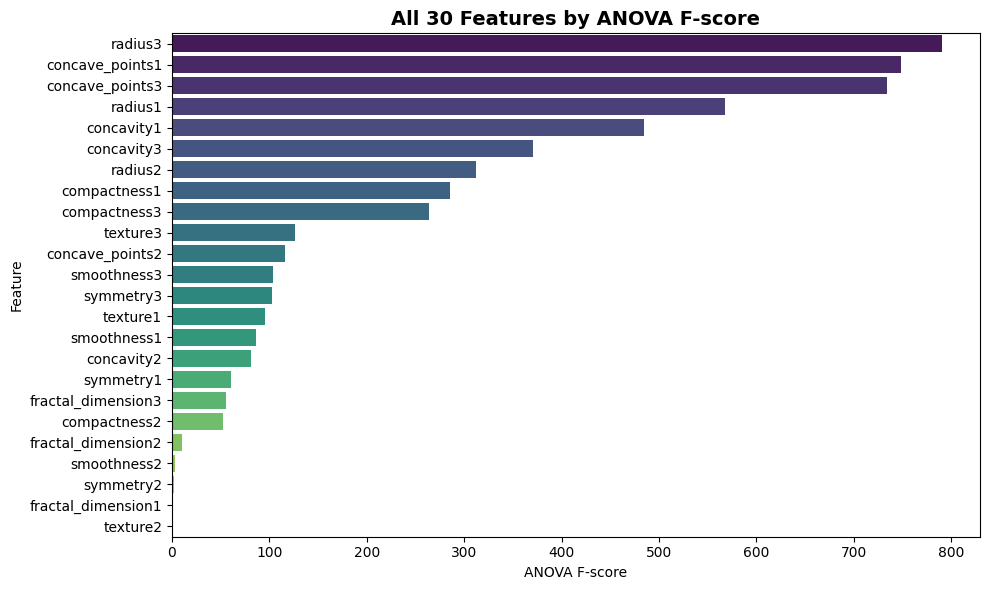

In [33]:
plt.figure(figsize=(10, 6))
top_n = scores_df.head(30)
sns.barplot(x='F-score', y='Feature', data=top_n, palette='viridis')
plt.xlabel('ANOVA F-score')
plt.title('All 30 Features by ANOVA F-score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()




### Principal Component Analysis (PCA)


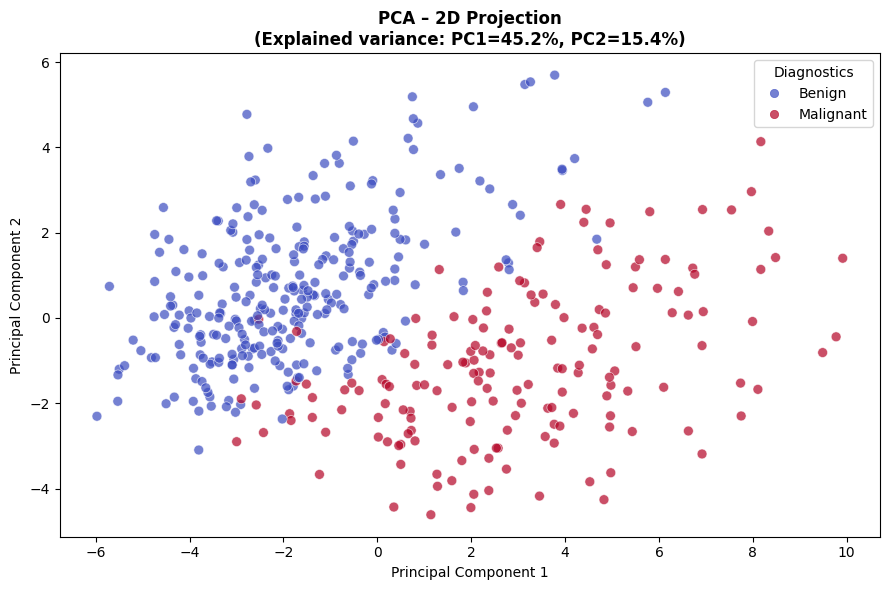

In [34]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='coolwarm', 
                      alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

handles, _ = scatter.legend_elements()
plt.legend(handles, ['Benign', 'Malignant'], title="Diagnostics")

plt.title(f'PCA – 2D Projection\n'
          f'(Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, '
          f'PC2={pca.explained_variance_ratio_[1]:.1%})',
          fontsize=12, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()



***Variance explained by all components***

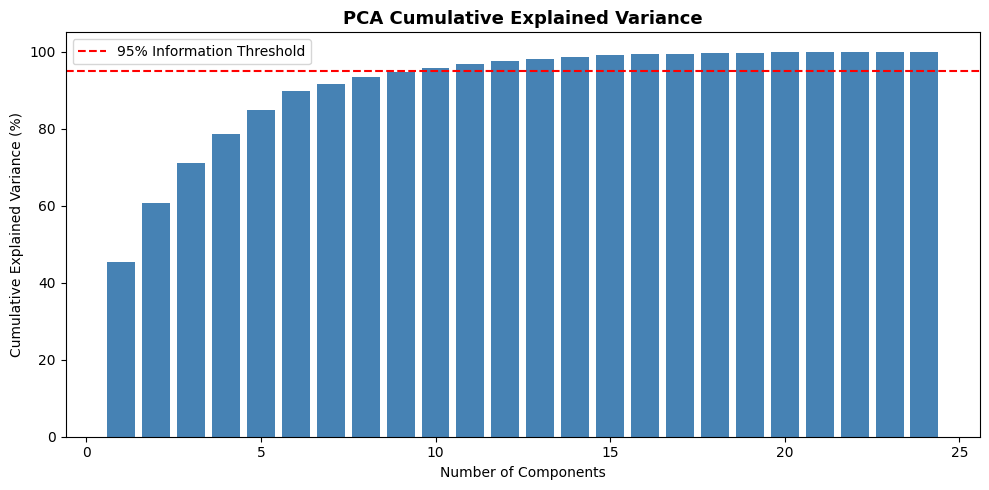

In [35]:
pca_full = PCA().fit(X_train_scaled)
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(pca_full.explained_variance_ratio_)+1),
       np.cumsum(pca_full.explained_variance_ratio_)*100, color='steelblue')
plt.axhline(95, color='red', linestyle='--', label='95% Information Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Cumulative Explained Variance', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


### Baseline Models Evaluation (Cross-Validation)


In [36]:
models = {
    'Logistic Regression':      LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors':      KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine':   SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree':            DecisionTreeClassifier(random_state=42),
    'Random Forest':            RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':        GradientBoostingClassifier(random_state=42),
    'AdaBoost':                 AdaBoostClassifier(random_state=42),
    'Naive Bayes':              GaussianNB(),
}

In [37]:
cv_means = []
cv_names = []

print("Comparing baseline models using 5-Fold Cross-Validation on TRAINING Data:")
for name, model in models.items():
    
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    mean_acc = cv_scores.mean() * 100
    std_acc = cv_scores.std() * 100
    print(f"{name:<25} CV Accuracy: {mean_acc:.2f}%  (± {std_acc:.2f}%)")
    
    cv_names.append(name)
    cv_means.append(mean_acc)


Comparing baseline models using 5-Fold Cross-Validation on TRAINING Data:
Logistic Regression       CV Accuracy: 97.58%  (± 1.28%)
K-Nearest Neighbors       CV Accuracy: 95.82%  (± 1.08%)
Support Vector Machine    CV Accuracy: 97.58%  (± 1.28%)
Decision Tree             CV Accuracy: 94.73%  (± 4.36%)
Random Forest             CV Accuracy: 96.04%  (± 3.00%)
Gradient Boosting         CV Accuracy: 94.95%  (± 3.78%)
AdaBoost                  CV Accuracy: 96.04%  (± 2.37%)
Naive Bayes               CV Accuracy: 92.75%  (± 2.04%)


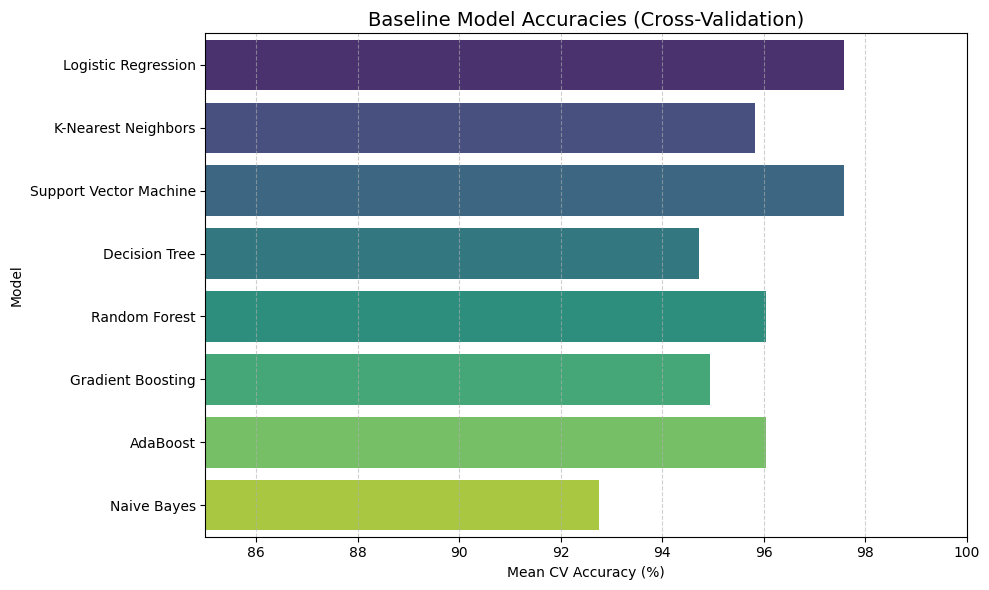

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(x=cv_means, y=cv_names, hue=cv_names, palette='viridis', legend=False)

plt.title('Baseline Model Accuracies (Cross-Validation)', fontsize=14)
plt.xlabel('Mean CV Accuracy (%)')
plt.ylabel('Model')
plt.xlim(85, 100) 
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Hyperparameter Tuning (GridSearchCV)


***for AdaBoost***


In [39]:
ada_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 1.0, 1.5]
}

print("Starting..")
ada_grid = GridSearchCV(AdaBoostClassifier(random_state=42), ada_param_grid, cv=5, scoring='accuracy')
ada_grid.fit(X_train_scaled, y_train)

print(f"Best AdaBoost Parameters: {ada_grid.best_params_}")
best_ada = ada_grid.best_estimator_

print("final accuracy using test data")
ada_preds = best_ada.predict(X_test_scaled)
ada_acc = accuracy_score(y_test, ada_preds)
ada_recall = recall_score(y_test, ada_preds)

print(f"Final Test Accuracy: {ada_acc * 100:.2f}%")
print(f"Recall (Malignant): {ada_recall * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, ada_preds, target_names=['Benign', 'Malignant']))

Starting..
Best AdaBoost Parameters: {'learning_rate': 1.0, 'n_estimators': 200}
final accuracy using test data
Final Test Accuracy: 97.37%
Recall (Malignant): 92.86%
Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



***for SVM***


In [40]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

grid_search = GridSearchCV(SVC(probability=True, random_state=42), param_grid, cv=5, scoring='accuracy')

print("Starting..")
grid_search.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
best_svm = grid_search.best_estimator_

print("final accuracy using test data")
final_preds_test = best_svm.predict(X_test_scaled)
test_acc = accuracy_score(y_test, final_preds_test)
test_recall = recall_score(y_test, final_preds_test)

print(f"Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"Recall (Malignant): {test_recall * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, final_preds_test, target_names=['Benign', 'Malignant']))

Starting..
Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
final accuracy using test data
Final Test Accuracy: 96.49%
Recall (Malignant): 92.86%
Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



***for Logistic Regression***

In [41]:
log_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # works perfectly for our small biological datasets and supports both l1 and l2
}

print("Starting..")
log_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), log_param_grid, cv=5, scoring='accuracy')
log_grid.fit(X_train_scaled, y_train)

print(f"Best Parameters: {log_grid.best_params_}")
best_log = log_grid.best_estimator_

print("final accuracy using test data")
log_preds = best_log.predict(X_test_scaled)
log_acc = accuracy_score(y_test, log_preds)
log_recall = recall_score(y_test, log_preds)

print(f" Test Accuracy: {log_acc * 100:.2f}%")
print(f"Recall (Malignant): {log_recall * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, log_preds, target_names=['Benign', 'Malignant']))

Starting..
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
final accuracy using test data
 Test Accuracy: 98.25%
Recall (Malignant): 95.24%
Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Post-Tuning Performance & ROC / Confusion Matrix Analysis


 ***SUPPORT VECTOR MACHINE (SVM)***

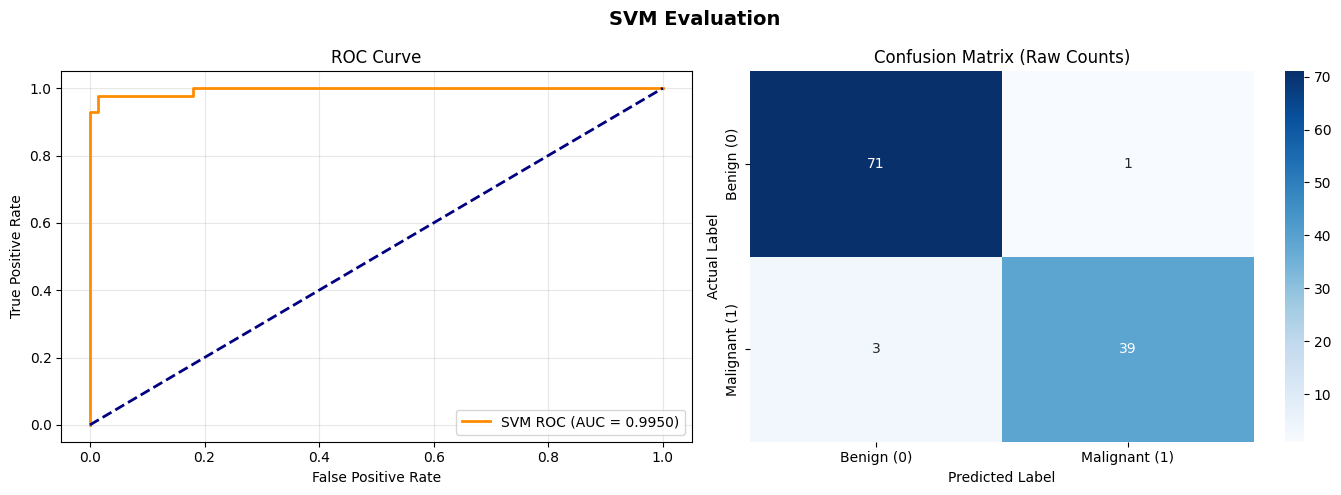

In [42]:

y_prob_svm = best_svm.predict_proba(X_test_scaled)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)
cm_svm = confusion_matrix(y_test, final_preds_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SVM Evaluation', fontsize=14, fontweight='bold')

# ROC
axes[0].plot(fpr_svm, tpr_svm, color='darkorange', lw=2, label=f'SVM ROC (AUC = {roc_auc_svm:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Confusion Matrix
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
axes[1].set_title('Confusion Matrix (Raw Counts)')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

***ADABOOST***

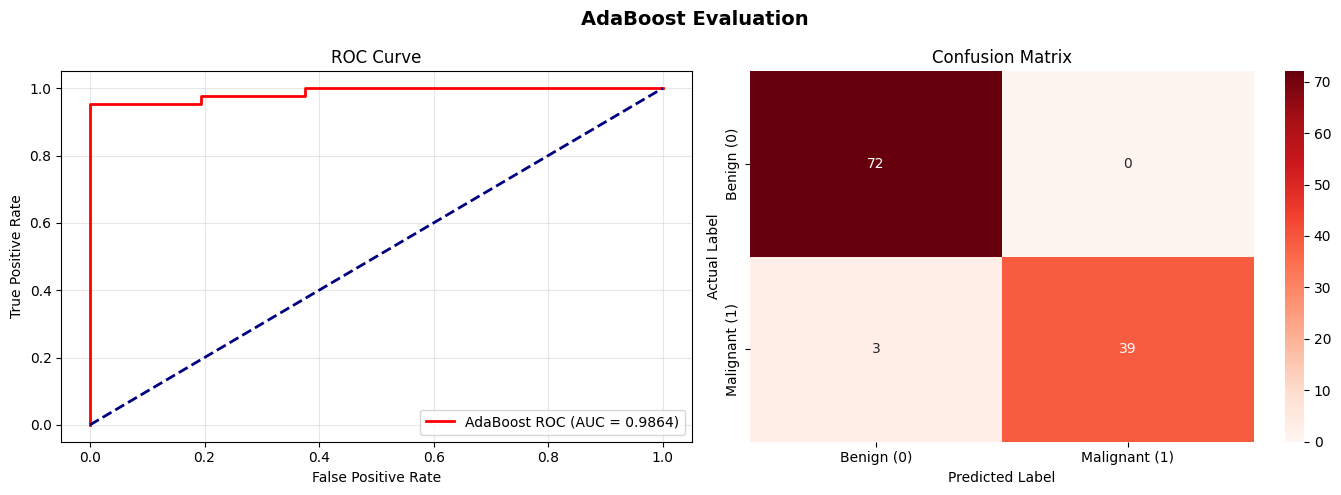

In [43]:
y_prob_ada = best_ada.predict_proba(X_test_scaled)[:, 1]
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
roc_auc_ada = auc(fpr_ada, tpr_ada)
cm_ada = confusion_matrix(y_test, ada_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AdaBoost Evaluation', fontsize=14, fontweight='bold')

# ROC
axes[0].plot(fpr_ada, tpr_ada, color='red', lw=2, label=f'AdaBoost ROC (AUC = {roc_auc_ada:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Confusion Matrix
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
axes[1].set_title('Confusion Matrix')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

***LOGISTIC REGRESSION***

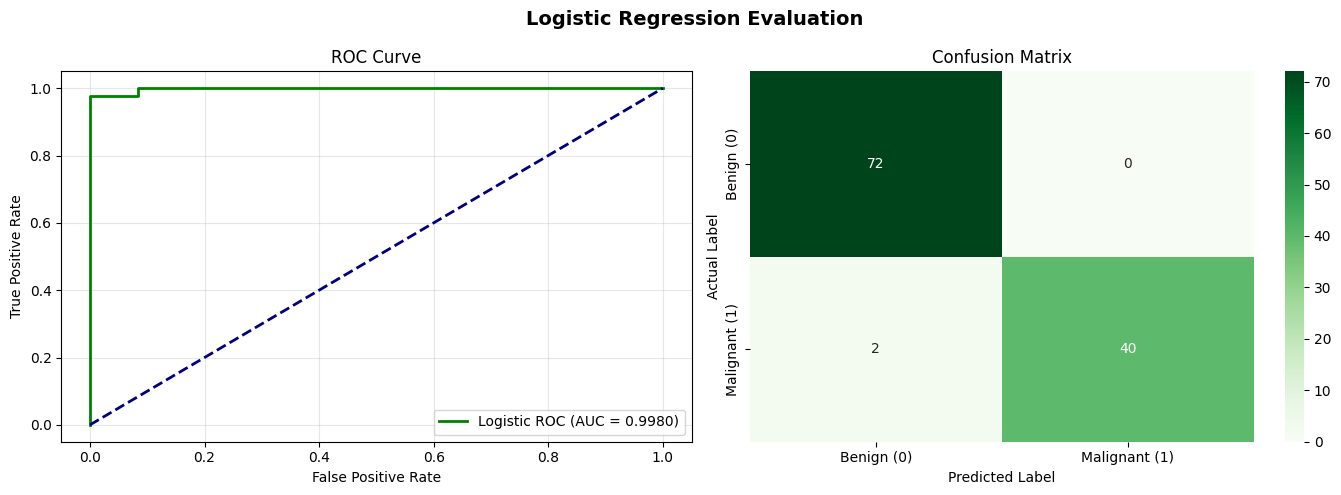

In [44]:
y_prob_log = best_log.predict_proba(X_test_scaled)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)
cm_log = confusion_matrix(y_test, log_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression Evaluation', fontsize=14, fontweight='bold')

# ROC
axes[0].plot(fpr_log, tpr_log, color='green', lw=2, label=f'Logistic ROC (AUC = {roc_auc_log:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Confusion Matrix
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
axes[1].set_title('Confusion Matrix')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

now using top 20 features

In [45]:
X_train_top25 = selector.transform(X_train_scaled)
X_test_top255 = selector.transform(X_test_scaled)

print(f"Original Training Shape: {X_train_scaled.shape}")
print(f"New Training Shape: {X_train_top25.shape}  <- 4 features removed!")

print("Comparing baseline models using the Top 20 Features")

for name, model in models.items():
    cv_scores_top25 = cross_val_score(model, X_train_top25, y_train, cv=5, scoring='accuracy')
    
    mean_acc = cv_scores_top25.mean() * 100
    std_acc = cv_scores_top25.std() * 100
    print(f"{name:<25} CV Accuracy (20 Feats): {mean_acc:.2f}%  (± {std_acc:.2f}%)")

Original Training Shape: (455, 24)
New Training Shape: (455, 20)  <- 4 features removed!
Comparing baseline models using the Top 20 Features
Logistic Regression       CV Accuracy (20 Feats): 97.14%  (± 1.49%)
K-Nearest Neighbors       CV Accuracy (20 Feats): 96.48%  (± 1.46%)
Support Vector Machine    CV Accuracy (20 Feats): 97.58%  (± 1.46%)
Decision Tree             CV Accuracy (20 Feats): 93.41%  (± 2.31%)
Random Forest             CV Accuracy (20 Feats): 96.48%  (± 2.98%)
Gradient Boosting         CV Accuracy (20 Feats): 94.95%  (± 3.91%)
AdaBoost                  CV Accuracy (20 Feats): 96.70%  (± 2.51%)
Naive Bayes               CV Accuracy (20 Feats): 92.75%  (± 2.04%)


### Explainability: Feature Importance for Cancer Predictions

To ensure our machine learning model is completely interpretable in a medical context, we visualize the true feature drivers. Instead of a black box, we extract exactly which physical tumor characteristics drive a Malignant (`1`) target.

***We train a clear Random Forest model on the top 20 features to extract clear, rule-based feature importance***


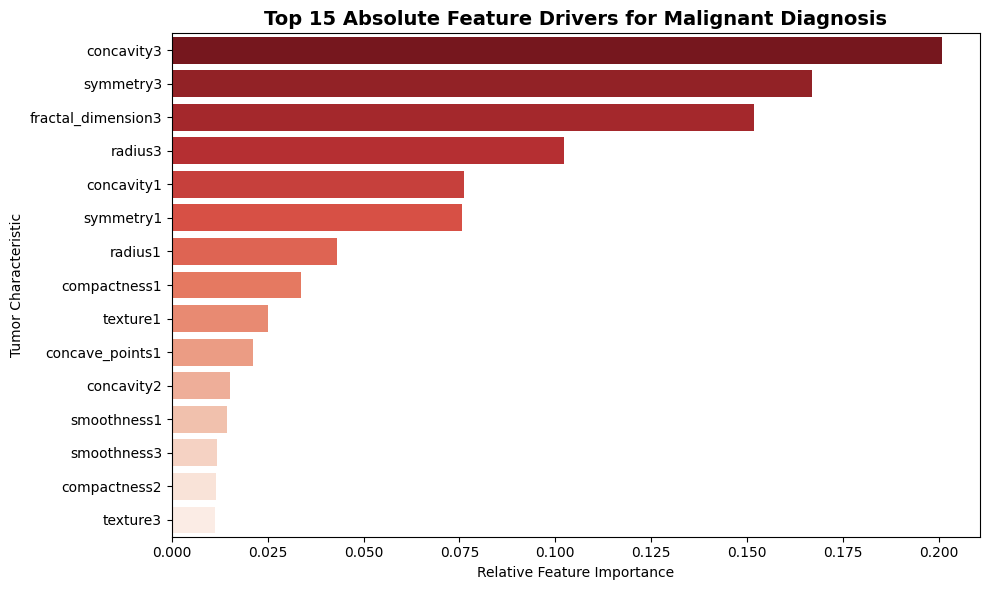

In [46]:
explainer_rf = RandomForestClassifier(n_estimators=100, random_state=42)
explainer_rf.fit(X_train_top25, y_train)

selected_feature_names = scores_df.head(20)['Feature'].values
importances = explainer_rf.feature_importances_

feat_imp = pd.DataFrame({'Feature': selected_feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15), palette='Reds_r')
plt.title('Top 15 Absolute Feature Drivers for Malignant Diagnosis', fontsize=14, fontweight='bold')
plt.xlabel('Relative Feature Importance')
plt.ylabel('Tumor Characteristic')
plt.tight_layout()
plt.show()